# ASWIFT SI_9 — FIG_4-style outlier-cutoff comparison

This notebook makes an SI figure using the same method colors, markers, typography, and block-statistic logic as FIG_4, but it only plots the original FIG_4 columns 2 and 3:

1. normalized signal block mean
2. block standard deviation

It compares three method-result CSV files corresponding to 10 MAD, 20 MAD, and no outlier cutoff (`infmad`). Rows are grouped by matrix: all Blood rows first, followed by all ISF rows.

Unlike FIG_4, this notebook does **not** apply manual y-axis limits and uses **log scaling** for the standard-deviation axis. This is intended to show the raw effect of different outlier filtering cutoffs on the non-ASWIFT methods.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Mapping, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# ASWIFT-friendly plotting defaults copied from FIG_4 style
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.default": "it",
})


def lighten_color(color, amount=0.68):
    import matplotlib.colors as mc
    c = np.array(mc.to_rgb(color))
    return tuple((1 - amount) * c + amount * np.ones(3))


def save_figure_multi(fig, stem, out_dir="figure_exports"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{stem}.png", transparent=True)
    fig.savefig(out_dir / f"{stem}.pdf", transparent=True)
    fig.savefig(out_dir / f"{stem}.svg", transparent=True)
    print(f"Saved to: {out_dir.resolve()}")


METHODS = {
    "aswift": "ASWIFT",
    "poly_linear": "Polynomial",
    "plaxco_gauss": "Multi-Gaussian",
    "justine_ewd": "Extend-Wavelet",
}

METHOD_STYLE = {
    "aswift": {
        "color": "#1f77b4",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "zorder": 20.0,
    },
    "poly_linear": {
        "color": "#ff7f0e",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "zorder": 3.0,
    },
    "plaxco_gauss": {
        "color": "#2ca02c",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "zorder": 3.0,
    },
    "justine_ewd": {
        "color": "#d62728",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "zorder": 3.0,
    },
}


def _plot_order_with_aswift_last(methods: Mapping[str, str]) -> list[str]:
    """Plot non-ASWIFT methods first and ASWIFT last so ASWIFT remains visually on top."""
    order = [method for method in methods if method != "aswift"]
    if "aswift" in methods:
        order.append("aswift")
    return order


def _method_offsets(values: Sequence[float] | np.ndarray | None, methods: Mapping[str, str]) -> dict[str, float]:
    """Return per-method plotting offsets, preserving method order."""
    if values is None:
        return {method: 0.0 for method in methods}
    vals = np.asarray(values, dtype=float).ravel()
    if vals.size != len(methods):
        raise ValueError(f"Expected {len(methods)} method offsets, but got {vals.size}.")
    return {method: float(offset) for method, offset in zip(methods.keys(), vals)}


def _coerce_exclude_indices(exclude_indices: Sequence[int] | np.ndarray | None) -> np.ndarray:
    if exclude_indices is None:
        return np.array([], dtype=int)
    return np.asarray(exclude_indices, dtype=int).ravel()


def _drop_excluded_rows(df: pd.DataFrame, exclude_indices: Sequence[int] | np.ndarray | None) -> pd.DataFrame:
    excluded = _coerce_exclude_indices(exclude_indices)
    if excluded.size == 0:
        return df.copy()
    keep = np.ones(len(df), dtype=bool)
    valid = excluded[(excluded >= 0) & (excluded < len(df))]
    keep[valid] = False
    return df.iloc[keep].copy()


def _infer_time_column(df: pd.DataFrame, candidates: Sequence[str] | None = None) -> str:
    if candidates is None:
        candidates = (
            "time_min", "time_minutes", "minutes", "min",
            "time_h", "time_hr", "time_hours", "hours", "hour", "elapsed_hours", "time",
        )
    lower_map = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise KeyError(
        "Could not find a time column in the results table. "
        f"Tried: {list(candidates)}\nAvailable columns:\n{list(df.columns)}"
    )


def _time_values_to_minutes(values: np.ndarray, *, time_unit: str = "hours") -> np.ndarray:
    """Convert time values to minutes."""
    t = np.asarray(values, dtype=float)
    unit = str(time_unit).lower()
    if unit in {"hour", "hours", "h", "hr", "hrs"}:
        return 60.0 * t
    if unit in {"minute", "minutes", "min", "mins", "m"}:
        return t
    if unit in {"second", "seconds", "sec", "secs", "s"}:
        return t / 60.0
    raise ValueError(f"Unsupported time_unit={time_unit!r}. Use 'hours', 'minutes', or 'seconds'.")


def _filter_start_time(time_min: np.ndarray, signal: np.ndarray, *, start_time_min: float | None = None):
    if start_time_min is None:
        return time_min, signal
    keep = np.asarray(time_min, dtype=float) >= float(start_time_min)
    return np.asarray(time_min)[keep], np.asarray(signal)[keep]


def _get_signal_series(df: pd.DataFrame, *, freq_hz: int, channel: int, method: str) -> np.ndarray:
    col = f"signal-{freq_hz}hz-ch{channel}-{method}"
    if col not in df.columns:
        raise KeyError(
            f"Missing column {col!r}. Available signal columns include:\n"
            + "\n".join(str(c) for c in df.columns if str(c).startswith("signal-"))
        )
    return df[col].to_numpy(dtype=float)


def _block_reduce(x: np.ndarray, block_size: int = 5):
    n_blocks = len(x) // block_size
    if n_blocks <= 0:
        raise ValueError("No complete blocks available for the requested block size.")
    trimmed = x[: n_blocks * block_size]
    blocks = trimmed.reshape(n_blocks, block_size)
    means = np.mean(blocks, axis=1)
    stds = np.std(blocks, axis=1, ddof=1)
    return means, stds, blocks


def _block_time_from_df(time_values: np.ndarray, block_size: int = 5) -> np.ndarray:
    t = np.asarray(time_values, float)
    t = t[np.isfinite(t)]
    n_blocks = len(t) // block_size
    if n_blocks <= 0:
        raise ValueError("No complete time blocks available for the requested block size.")
    trimmed = t[: n_blocks * block_size]
    return trimmed.reshape(n_blocks, block_size).mean(axis=1)


def _compute_stats_like_original(
    df: pd.DataFrame,
    *,
    freq_hz: int,
    channel: int,
    methods: Mapping[str, str],
    block_size: int = 5,
    baseline_n: int = 5,
    time_column: str = "time",
    time_unit: str = "hours",
    exclude_indices: Sequence[int] | np.ndarray | None = None,
    start_time_min: float | None = None,
):
    df = _drop_excluded_rows(df, exclude_indices)
    time_min_all = _time_values_to_minutes(df[time_column].to_numpy(float), time_unit=time_unit)

    stats = {}
    for method in methods:
        s_all = _get_signal_series(df, freq_hz=freq_hz, channel=channel, method=method)

        # Keep time and signal aligned after finite filtering. The start-time clip is applied
        # before normalization, so the baseline is calculated from the first points after the clip.
        keep = np.isfinite(time_min_all) & np.isfinite(s_all)
        time_min, s = _filter_start_time(time_min_all[keep], s_all[keep], start_time_min=start_time_min)
        if len(s) < baseline_n:
            raise ValueError(
                f"Need at least {baseline_n} finite, non-excluded points after start_time_min "
                f"for normalization of {method} ch{channel}; got {len(s)}."
            )
        baseline = 1.0 if baseline_n == 0 else float(np.mean(s[:baseline_n]))
        if not np.isfinite(baseline) or baseline == 0:
            raise ValueError(f"Invalid normalization baseline for {method} ch{channel}: {baseline}.")
        s_norm = s / baseline

        means, stds, blocks = _block_reduce(s_norm, block_size=block_size)
        block_time_min = _block_time_from_df(time_min, block_size=block_size)
        n = min(len(block_time_min), len(means))
        stats[method] = {
            "time_min": block_time_min[:n],
            "mean": means[:n],
            "std": stds[:n],
        }
    return stats


def _plot_signal_row(
    ax_sig,
    *,
    stats: dict,
    methods: Mapping[str, str],
    ylabel: str | None = None,
    target_injection_min: float | None = None,
    show_uncertainty: bool = False,
    uncertainty_alpha: float = 0.35,
    errorbar_alpha: float = 0.65,
    method_time_offsets_min: Sequence[float] | np.ndarray | None = None,
    other_methods_alpha: float = 0.55,
    aswift_alpha: float = 1.0,
):
    if target_injection_min is not None:
        ax_sig.axvline(target_injection_min, color="black", linestyle="--", linewidth=1.2, zorder=0)

    offsets = _method_offsets(method_time_offsets_min, methods)

    for method in _plot_order_with_aswift_last(methods):
        st = METHOD_STYLE[method]
        color = st["color"]
        alpha = aswift_alpha if method == "aswift" else other_methods_alpha
        zorder = st["zorder"]
        lighter = lighten_color(color, amount=0.68)
        t = stats[method]["time_min"] + offsets[method]
        y = stats[method]["mean"]
        yerr = stats[method]["std"]
        keep_sig = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr)

        if show_uncertainty:
            ax_sig.fill_between(
                t[keep_sig],
                (y - 0.70 * yerr)[keep_sig],
                (y + 0.70 * yerr)[keep_sig],
                color=lighter,
                alpha=uncertainty_alpha * alpha,
                linewidth=0,
                zorder=zorder - 1,
            )
            ax_sig.errorbar(
                t[keep_sig],
                y[keep_sig],
                yerr=yerr[keep_sig],
                fmt="none",
                ecolor=lighter,
                alpha=errorbar_alpha * alpha,
                elinewidth=1.1,
                capsize=2.3,
                capthick=1.0,
                zorder=zorder,
            )

        ax_sig.plot(
            t[keep_sig], y[keep_sig],
            color=color,
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            marker=st["marker"],
            markersize=st["markersize"],
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.45,
            alpha=alpha,
            zorder=zorder + 1,
        )

    if ylabel:
        ax_sig.set_ylabel(ylabel)
    else:
        ax_sig.set_ylabel("")
    ax_sig.set_xlabel("Time, min")


def _plot_method_std_row(
    ax_std,
    *,
    stats: dict,
    methods: Mapping[str, str],
    ylabel: str | None = None,
    target_injection_min: float | None = None,
    log_scale: bool = False,
    method_time_offsets_min: Sequence[float] | np.ndarray | None = None,
    other_methods_alpha: float = 0.55,
    aswift_alpha: float = 1.0,
):
    if target_injection_min is not None:
        ax_std.axvline(target_injection_min, color="black", linestyle="--", linewidth=1.2, zorder=0)

    offsets = _method_offsets(method_time_offsets_min, methods)

    for method in _plot_order_with_aswift_last(methods):
        st = METHOD_STYLE[method]
        color = st["color"]
        alpha = aswift_alpha if method == "aswift" else other_methods_alpha
        zorder = st["zorder"]
        t = stats[method]["time_min"] + offsets[method]
        y = stats[method]["std"]
        keep_std = np.isfinite(t) & np.isfinite(y)
        if log_scale:
            keep_std &= y > 0

        ax_std.plot(
            t[keep_std], y[keep_std],
            color=color,
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            marker=st["marker"],
            markersize=st["markersize"],
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.45,
            alpha=alpha,
            zorder=zorder + 1,
        )

    if log_scale:
        ax_std.set_yscale("log")
    if ylabel:
        ax_std.set_ylabel(ylabel)
    else:
        ax_std.set_ylabel("")
    ax_std.set_xlabel("Time, min")


def plot_figure_si_9_cutoff_comparison(
    cutoff_files: Sequence[dict],
    *,
    methods: Mapping[str, str] = METHODS,
    freq_hz: int = 200,
    block_size: int = 10,
    baseline_n: int = 20,
    channels: Sequence[tuple[int, str]] = ((0, "Blood"), (1, "ISF")),
    time_column_candidates: Sequence[str] = (
        "time_min", "time_minutes", "minutes", "min",
        "time_h", "time_hr", "time_hours", "hours", "hour", "elapsed_hours", "time",
    ),
    time_unit: str = "hours",
    exclude_indices: Sequence[int] | np.ndarray | None = None,
    start_time_min: float | None = None,
    target_injection_min: float | None = 30.0,
    target_injection_label: str = "Target Injection",
    method_time_offsets_min: Sequence[float] | np.ndarray | None = (0.0, 3.0, 6.0, 9.0),
    other_methods_alpha: float = 0.55,
    aswift_alpha: float = 1.0,
    show_uncertainty: bool = False,
    std_log_scale: bool = True,
    save_stem: str | None = None,
):
    """
    Plot an SI comparison of the FIG_4 normalized-signal and block-SD panels
    across multiple outlier-cutoff method-result CSVs.

    This intentionally applies no manual y-axis limits. `std_log_scale` defaults to True
    so the standard-deviation column is shown on a log scale.
    """
    n_file_groups = len(cutoff_files)
    n_channels = len(channels)
    nrows = n_file_groups * n_channels
    ncols = 2

    fig_height = max(3.0, 1.65 * nrows + 3.8)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.8, fig_height), sharex=False, squeeze=False)

    # Row order is grouped by biological matrix:
    # all Blood cutoffs first, followed by all ISF cutoffs.
    csv_cache: dict[Path, tuple[pd.DataFrame, str]] = {}
    row = 0
    for channel, medium_label in channels:
        for cutoff in cutoff_files:
            label = cutoff["label"]
            csv_path = Path(cutoff["path"])
            if not csv_path.exists():
                raise FileNotFoundError(
                    f"Could not find {csv_path}. Check DATA_DIR and cutoff_files in the config cell."
                )
            if csv_path not in csv_cache:
                df = pd.read_csv(csv_path)
                time_col = _infer_time_column(df, candidates=time_column_candidates)
                csv_cache[csv_path] = (df, time_col)
            else:
                df, time_col = csv_cache[csv_path]

            stats = _compute_stats_like_original(
                df,
                freq_hz=freq_hz,
                channel=channel,
                methods=methods,
                block_size=block_size,
                baseline_n=baseline_n,
                time_column=time_col,
                time_unit=time_unit,
                exclude_indices=exclude_indices,
                start_time_min=start_time_min,
            )

            ax_sig = axes[row, 0]
            ax_std = axes[row, 1]
            _plot_signal_row(
                ax_sig,
                stats=stats,
                methods=methods,
                ylabel=None,
                target_injection_min=target_injection_min,
                show_uncertainty=show_uncertainty,
                method_time_offsets_min=method_time_offsets_min,
                other_methods_alpha=other_methods_alpha,
                aswift_alpha=aswift_alpha,
            )
            _plot_method_std_row(
                ax_std,
                stats=stats,
                methods=methods,
                ylabel=None,
                target_injection_min=target_injection_min,
                log_scale=std_log_scale,
                method_time_offsets_min=method_time_offsets_min,
                other_methods_alpha=other_methods_alpha,
                aswift_alpha=aswift_alpha,
            )

            # Row annotation names the biological matrix and cutoff without adding extra columns.
            ax_sig.text(
                -0.28, 0.5,
                f"{label}\n{medium_label}",
                transform=ax_sig.transAxes,
                ha="right",
                va="center",
                fontsize=10,
                fontweight="bold",
                rotation=0,
            )

            if row == 0:
                ax_sig.set_title("Normalized Signal")
                ax_std.set_title("Std. Dev.")

            row += 1


    method_handles = []
    for method_key, method_label in methods.items():
        st = METHOD_STYLE[method_key]
        method_handles.append(
            Line2D(
                [0], [0],
                color=st["color"],
                linestyle=st["linestyle"],
                linewidth=st["linewidth"],
                marker=st["marker"],
                markersize=st["markersize"],
                markerfacecolor=st["color"],
                markeredgecolor="black",
                markeredgewidth=0.45,
                label=method_label,
            )
        )

    if target_injection_min is not None:
        method_handles.append(
            Line2D([0], [0], color="black", linestyle="--", linewidth=1.2, label=target_injection_label)
        )

    fig.legend(
        handles=method_handles,
        loc="lower center",
        ncol=len(method_handles),
        frameon=True,
        fancybox=False,
        edgecolor="black",
        facecolor="white",
        bbox_to_anchor=(0.5, 0.015),
        handlelength=2.2,
        columnspacing=1.8,
        borderpad=0.8,
    )

    fig.subplots_adjust(top=0.975, bottom=0.085, left=0.20, right=0.985, wspace=0.34, hspace=0.62)

    if save_stem is not None:
        save_figure_multi(fig, save_stem)

    return fig, axes


Saved to: /Users/Max_1/PycharmProjects/aswift_figures/figures/figure_exports


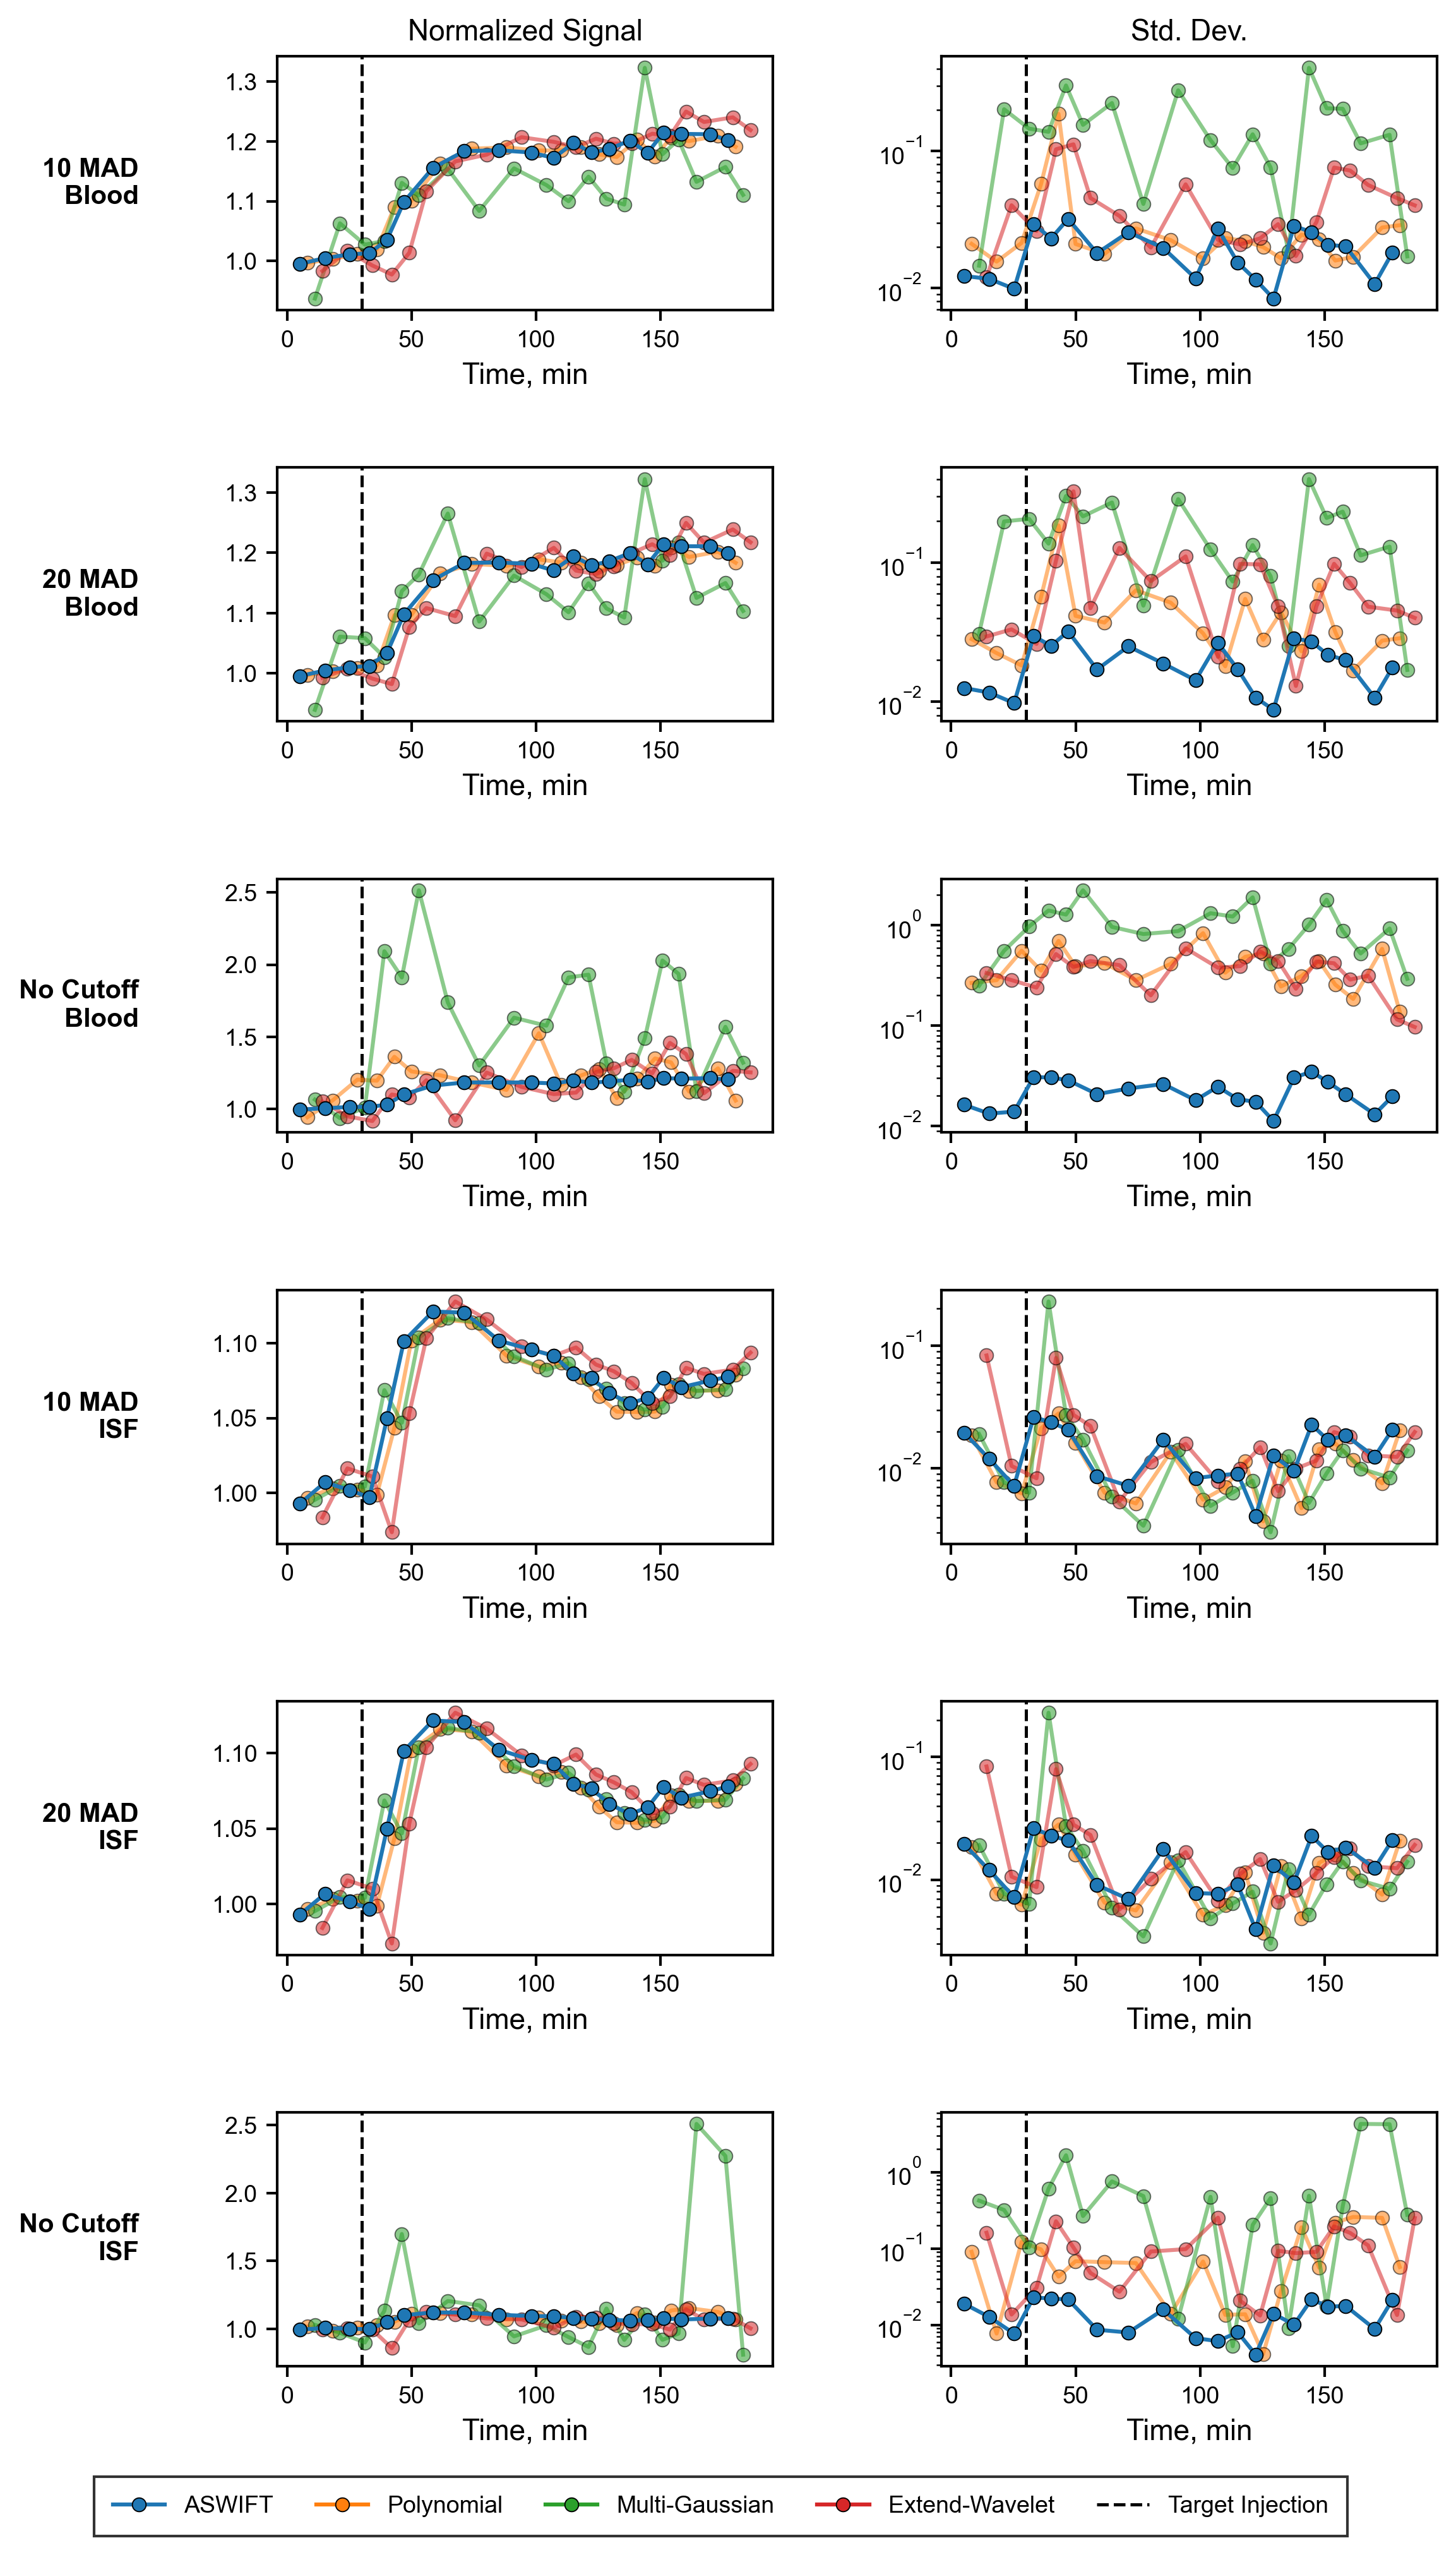

In [2]:
# -----------------------------
# User inputs / run cell
# -----------------------------
methods = {
    "aswift": "ASWIFT",
    "poly_linear": "Polynomial",
    "plaxco_gauss": "Multi-Gaussian",
    "justine_ewd": "Extend-Wavelet",
}

# Folder containing the three method-result CSV files.
DATA_DIR = Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/')

cutoff_files = [
    {
        "label": "10 MAD",
        "path": DATA_DIR / '20250502_Fig5a_BICEP_csv_methods_results_10mad.csv',
    },
    {
        "label": "20 MAD",
        "path": DATA_DIR / '20250502_Fig5a_BICEP_csv_methods_results_20mad.csv',
    },
    {
        "label": "No Cutoff",
        "path": DATA_DIR / '20250502_Fig5a_BICEP_csv_methods_results_infmad.csv',
    },
]

# Zero-based row/acquisition indices to remove from every calculation and plot.
# This keeps the partial-run exclusions from FIG_4 but does not add any extra
# outlier exclusions; the three CSV files themselves encode the outlier cutoff.
partial_indices = np.array([3, 5, 6, 7, 9, 10, 11, 18, 21, 27, 29, 33, 36, 39, 114, 121, 195, 198, 199, 200, 207, 225, 226], dtype=int)
exclude_indices = partial_indices

# Optional time clip in minutes. Set to None to keep all data.
start_time_min = None

# Block-statistic settings matched to the FIG_4 notebook.
freq_hz = 200
block_size = 10
baseline_n = 20
time_unit = "hours"
target_injection_min = 30.0
method_time_offsets_min = (0.0, 3.0, 6.0, 9.0)

# Important for this SI figure:
# - No manual y-axis limits are applied anywhere.
# - The SD axis is shown on a log scale.
std_log_scale = True

fig, axes = plot_figure_si_9_cutoff_comparison(
    cutoff_files,
    methods=methods,
    freq_hz=freq_hz,
    block_size=block_size,
    baseline_n=baseline_n,
    channels=((0, "Blood"), (1, "ISF")),
    time_unit=time_unit,
    exclude_indices=exclude_indices,
    start_time_min=start_time_min,
    target_injection_min=target_injection_min,
    target_injection_label="Target Injection",
    method_time_offsets_min=method_time_offsets_min,
    show_uncertainty=False,
    std_log_scale=std_log_scale,
    save_stem="SI_9",
)

plt.show()
